In [1]:
import qutip as qt
from qutip import *
import matplotlib.pyplot as plt
import numpy as np

## general solution for g(t)

In [2]:
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import quad
from scipy.special import gamma, zeta, eval_hermite, factorial

kappa = 2.5e-3*2*np.pi*2

def sech(x):
    return 1 / np.cosh(x)

_kappa_cache = {}

def _N_m(m, kappa):
    numerator = 8 * (1 - 2**(1 - 2*m)) * gamma(2*m + 1) * zeta(2*m)
    denominator = kappa**(2*m + 1)
    return 1.0 / (numerator / denominator)

def _compute_Z_m(m, A_coeffs, kappa):
    Z = 0.0
    for k in range(m // 2 + 1):
        deg_k = m - 2 * k
        A_k = A_coeffs[deg_k]
        inner_sum = 0.0
        for l in range(m // 2 + 1):
            deg_l = m - 2 * l
            A_l = A_coeffs[deg_l]
            Nj_index = m - (k + l)
            Nj = _N_m(Nj_index, kappa)
            inner_sum += A_l / Nj
        Z += A_k * inner_sum
    return 1 / Z

def _get_A_m(m, kappa):
    if kappa not in _kappa_cache:
        _kappa_cache[kappa] = {
            "A_list": {0: [1.0]},
            "Z_dict": {0: kappa / 4},
        }

    A_list = _kappa_cache[kappa]["A_list"]
    Z_dict = _kappa_cache[kappa]["Z_dict"]

    if m in A_list:
        return A_list[m]

    A_m_coeffs = [0.0] * (m + 1)
    A_m_coeffs[m] = 1.0

    for i in range(1, m // 2 + 1):
        lower_m = m - 2 * i
        A_lower = _get_A_m(lower_m, kappa)

        inner_sum = 0.0
        for j in range(0, (m // 2 - i) + 1):
            index_in_A = m - 2 * (i + j)
            if 0 <= index_in_A < len(A_lower):
                A_coeff = A_lower[index_in_A]
                Nj = _N_m(m - (i + j), kappa)
                inner_sum += A_coeff / Nj

        Z = Z_dict.get(lower_m, 1.0)
        for power, coeff in enumerate(A_lower):
            if power < len(A_m_coeffs):
                A_m_coeffs[power] -= inner_sum * Z * coeff

    Z_m = _compute_Z_m(m, A_m_coeffs, kappa)
    Z_dict[m] = Z_m
    A_list[m] = A_m_coeffs
    return A_m_coeffs

def xi_m(t, m, kappa):
    A_coeffs = _get_A_m(m, kappa)
    Zm = _kappa_cache[kappa]["Z_dict"][m]
    A_val = sum(c * t**i for i, c in enumerate(A_coeffs))
    return np.sqrt(Zm) * sech(kappa * t / 2) * A_val

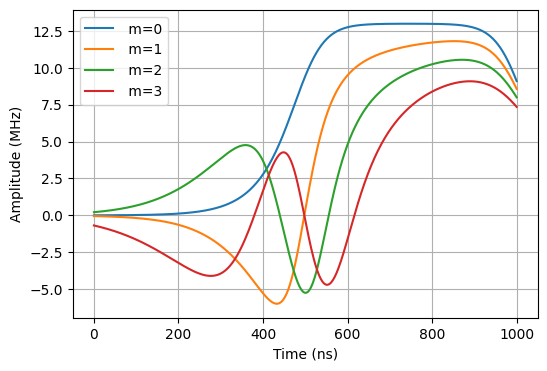

In [3]:
kappa =  0.14*2*np.pi
kappa_ph = 2.5e-3*2*np.pi*2
# t_vals = np.linspace(-500, 500, 501)
t_vals = np.linspace(0, 1000, 501)

def f(t, m, kappa):
    return xi_m(t-(t_vals[-1]-t_vals[0])/2, m, kappa)

def f_prime(t, m, kappa, h=1e-3):
    return (f(t + h, m, kappa) - f(t - h, m, kappa)) / (2 * h)

def compute_g(t_vals, m, kappa, kappa_ph):
    f_vals = f(t_vals, m, kappa_ph)
    f_prime_vals = f_prime(t_vals, m, kappa_ph)
    

    f2_vals = np.abs(f_vals)**2
    integral_vals = cumulative_trapezoid(f2_vals, t_vals, initial=0)
    
    numerator = f_prime_vals + (kappa * f_vals / 2)
    denominator = np.sqrt(kappa * (1 - integral_vals) - f2_vals)
    
    return numerator / denominator

plt.figure(figsize=(6, 4))
for m in range(4):
    g_vals = compute_g(t_vals, m, kappa, kappa_ph)
    plt.plot(t_vals, np.real(g_vals)/2/np.pi*1e3, label=fr" m={m}")

plt.xlabel("Time (ns)")
plt.ylabel("Amplitude (MHz)")
plt.legend()
plt.grid(True)
plt.show()


## QuTiP simulation

In [4]:
from datataking import search_datadict_miyamura
from qutip import fidelity, Qobj
from Analysis import (
    SpatiotemporalAnalysis,demodulate
)

In [5]:
result_dict_tx = dict(
    data_ph0 = dict(target_freq=9.38, date="2025-08-12", acquire_time="124754", duration=1000),
    data_ph1 = dict(target_freq=9.38, date="2025-08-12", acquire_time="124137", duration=1000),
    data_ph2 = dict(target_freq=9.38, date="2025-08-12", acquire_time="124227", duration=1000),
    data_ph3 = dict(target_freq=9.38, date="2025-08-12", acquire_time="125025", duration=1000),
)
result_dict_rx = dict(
    data_ph0 = dict(target_freq=9.38, date="2025-08-12", acquire_time="110853", duration=1000),
    data_ph1 = dict(target_freq=9.38, date="2025-08-12", acquire_time="110223", duration=1000),
    data_ph2 = dict(target_freq=9.38, date="2025-08-12", acquire_time="110313", duration=1000),
    data_ph3 = dict(target_freq=9.38, date="2025-08-12", acquire_time="110403", duration=1000),
)

num_of_ph_amp = 1
num_of_fogi_timing = 51
f_if = (9.5-9.38)*1e9

header = "data/"
ph0_fo0 = "/2025-08-13/2025-08-13T081809_9c21d1b7-j1_JPA_comm_timing"
ph0_fo1 = "/2025-08-12/2025-08-12T145332_addb4dad-j1_JPA_comm_timing"
ph0_fo2 = "/2025-08-12/2025-08-12T223011_78afd813-j1_JPA_comm_timing"
ph0_fo3 = "/2025-08-12/2025-08-12T162316_371a7ee5-j1_JPA_comm_timing"
ph1_fo0 = "/2025-08-12/2025-08-12T205345_fff72f75-j1_JPA_comm_timing"
ph1_fo1 = "/2025-08-12/2025-08-12T214421_11bce74b-j1_JPA_comm_timing"
ph1_fo2 = "/2025-08-12/2025-08-12T183812_10814b2f-j1_JPA_comm_timing"
ph1_fo3 = "/2025-08-12/2025-08-12T192312_59d17cb7-j1_JPA_comm_timing"
ph2_fo0 = "/2025-08-12/2025-08-12T200813_a3f91ff0-j1_JPA_comm_timing"
ph2_fo1 = "/2025-08-13/2025-08-13T010923_b6800336-j1_JPA_comm_timing"
ph2_fo2 = "/2025-08-13/2025-08-13T015414_fa4288d4-j1_JPA_comm_timing"
ph2_fo3 = "/2025-08-13/2025-08-13T023907_3f311ad9-j1_JPA_comm_timing"
ph3_fo0 = "/2025-08-13/2025-08-13T032400_84bc5ae9-j1_JPA_comm_timing"
ph3_fo1 = "/2025-08-13/2025-08-13T040856_cb5ba4f9-j1_JPA_comm_timing"
ph3_fo2 = "/2025-08-13/2025-08-13T045352_12672ec9-j1_JPA_comm_timing"
ph3_fo3 = "/2025-08-13/2025-08-13T053850_5a9232a6-j1_JPA_comm_timing"

acquisition_00 = SpatiotemporalAnalysis(header, ph0_fo0, header, result_dict_tx['data_ph0'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_01 = SpatiotemporalAnalysis(header, ph0_fo1, header, result_dict_tx['data_ph0'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_02 = SpatiotemporalAnalysis(header, ph0_fo2, header, result_dict_tx['data_ph0'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_03 = SpatiotemporalAnalysis(header, ph0_fo3, header, result_dict_tx['data_ph0'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_10 = SpatiotemporalAnalysis(header, ph1_fo0, header, result_dict_tx['data_ph1'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_11 = SpatiotemporalAnalysis(header, ph1_fo1, header, result_dict_tx['data_ph1'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_12 = SpatiotemporalAnalysis(header, ph1_fo2, header, result_dict_tx['data_ph1'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_13 = SpatiotemporalAnalysis(header, ph1_fo3, header, result_dict_tx['data_ph1'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_20 = SpatiotemporalAnalysis(header, ph2_fo0, header, result_dict_tx['data_ph2'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_21 = SpatiotemporalAnalysis(header, ph2_fo1, header, result_dict_tx['data_ph2'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_22 = SpatiotemporalAnalysis(header, ph2_fo2, header, result_dict_tx['data_ph2'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_23 = SpatiotemporalAnalysis(header, ph2_fo3, header, result_dict_tx['data_ph2'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_30 = SpatiotemporalAnalysis(header, ph3_fo0, header, result_dict_tx['data_ph3'], result_dict_rx['data_ph0'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_31 = SpatiotemporalAnalysis(header, ph3_fo1, header, result_dict_tx['data_ph3'], result_dict_rx['data_ph1'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_32 = SpatiotemporalAnalysis(header, ph3_fo2, header, result_dict_tx['data_ph3'], result_dict_rx['data_ph2'], num_of_ph_amp, num_of_fogi_timing, f_if)
acquisition_33 = SpatiotemporalAnalysis(header, ph3_fo3, header, result_dict_tx['data_ph3'], result_dict_rx['data_ph3'], num_of_ph_amp, num_of_fogi_timing, f_if)


In [6]:
acquisitions = [[None for _ in range(4)] for _ in range(4)]

acquisitions[0][0] = acquisition_00
acquisitions[0][1] = acquisition_01
acquisitions[0][2] = acquisition_02
acquisitions[0][3] = acquisition_03

acquisitions[1][0] = acquisition_10
acquisitions[1][1] = acquisition_11
acquisitions[1][2] = acquisition_12
acquisitions[1][3] = acquisition_13

acquisitions[2][0] = acquisition_20
acquisitions[2][1] = acquisition_21
acquisitions[2][2] = acquisition_22
acquisitions[2][3] = acquisition_23

acquisitions[3][0] = acquisition_30
acquisitions[3][1] = acquisition_31
acquisitions[3][2] = acquisition_32
acquisitions[3][3] = acquisition_33

### photon emission

In [7]:
n_cutoff_q = 3
n_cutoff_r = 2
n_cutoff_vc = 3

b = qt.tensor(qt.destroy(n_cutoff_q), qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))
a = qt.tensor(qt.qeye(n_cutoff_q), qt.destroy(n_cutoff_r), qt.qeye(n_cutoff_vc))
vc = qt.tensor(qt.qeye(n_cutoff_q), qt.qeye(n_cutoff_r), qt.destroy(n_cutoff_vc))

zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[0,1]=1
gedecayop=Qobj(zeromatrixxtmp)
etog = qt.tensor(gedecayop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))
zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[1,2]=1
efdecayop=Qobj(zeromatrixxtmp)
ftoe = qt.tensor(efdecayop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))
zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[0,0]=-1
zeromatrixxtmp[1,1]=1
gedechoop=Qobj(zeromatrixxtmp)
dechoge = qt.tensor(gedechoop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))
zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[1,1]=-1
zeromatrixxtmp[2,2]=1
efdechoop=Qobj(zeromatrixxtmp)
dechoef = qt.tensor(efdechoop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))

g0 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0))
f0 = qt.tensor(qt.basis(n_cutoff_q, 2), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0))
g1 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 1), qt.basis(n_cutoff_vc, 0))
e0 = qt.tensor(qt.basis(n_cutoff_q, 1), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0))
vc1 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 1))

alpha = -0.356 * 2 * np.pi
chi = -0.0076 * 2 * np.pi
eta = 0.67
kappa_r = 0.14 * 2 * np.pi
K = 0 * 2 * np.pi

H_fogi = (
    -alpha / 2 * b.dag()*b + alpha * b.dag()*b.dag()*b*b / 2
    +K * a.dag()*a.dag()*a*a / 2 + 2*chi*a.dag()*a*b.dag()*b
)

H_d = -a.dag()*b*b/np.sqrt(2)
H_c = 1j * (np.sqrt(kappa_r)/2) * vc.dag()*a

T1ge=29*1e3
T1ef=22*1e3
T2ge=5*1e3
T2ef=5*1e3
Tphige=1/((1/T2ge-1/T1ge/2)/2)
Tphief=1/((1/T2ef-1/T1ef/2)/2)

e_ops = []
options = qt.Options(atol=1e-9, rtol=1e-9, nsteps=1000, max_step=0.1, store_states=True)

c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


In [8]:
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d

T = 500 
N = 251
# tgrid = np.linspace(-T, T, N)
tgrid = np.linspace(0, 2*T, N)
dt = tgrid[1] - tgrid[0]
kappa_ph = 2.5e-3 * 2 * np.pi * 2

_eps = 1e-14
    
g_interps = []
g_interps_rvs = []

for m in range(4): 
    f_vals = f(tgrid, m, kappa_ph)
    f_prime_vals = f_prime(tgrid, m, kappa_ph) 
    f2_vals = np.abs(f_vals)**2
    integral_vals = cumulative_trapezoid(f2_vals, tgrid, initial=0)

    # numerator = f_prime_vals + (kappa_r * f_vals / 2)
    # denominator = np.sqrt(kappa_r * (1.0 - integral_vals) - f2_vals)
    numerator =  (kappa_r * f_vals / 2)
    denominator = np.sqrt(kappa_r * (1.0 - integral_vals))
    g_vals = numerator / denominator
    g_interp = interp1d(tgrid, np.real(g_vals), kind='cubic', fill_value='extrapolate')
    g_interps.append(g_interp)

    g_interp_rvs = interp1d(tgrid, np.real(g_vals[::-1]), kind='cubic', fill_value='extrapolate') 
    g_interps_rvs.append(g_interp_rvs)
    
g_u_interps = []
for m in range(4):
    ut_vals = xi_m(tgrid-(t_vals[-1]-t_vals[0])/2, m, kappa_ph) #` fix me
    cumint = cumulative_trapezoid(np.abs(ut_vals)**2, tgrid, initial=0)
    eps = 1e-14
    denom = np.sqrt(1.0 - cumint + eps)
    g_vals = np.conjugate(ut_vals) / denom
    g_interp = interp1d(tgrid, g_vals, kind='cubic', fill_value='extrapolate')
    g_u_interps.append(g_interp)
    
def g_u(t, args):
    m = int(args["input_num"])
    t_local = float(t)- float(args["center"])
    return float(args["g_u_interps"][m](t_local))

def g_u_conj(t, args):
    return np.conjugate(g_u(t, args))


def g_time(t, args):
    t_local = float(t) - float(args["center"])
    m = int(args["fogi_mode"])
    # access interpolant precomputed above (we'll pass lists via args)
    return float(args["g_interps"][m](t_local))

def g_time_conj(t, args):
    return np.conjugate(g_time(t, args))

def g_time_rvs(t, args):
    t_local = float(t) - float(args["center"])
    m = int(args["fogi_mode"])
    # access interpolant precomputed above (we'll pass lists via args)
    return float(args["g_interps_rvs"][m](t_local))

def g_time_conj_rvs(t, args):
    return np.conjugate(g_time_rvs(t, args))

base_args = {
    "center": 0,
    "fogi_mode": 0,
    "g_interps": g_interps,
    "g_interps_rvs": g_interps_rvs,
    "g_u_interps": g_u_interps,
    "input_num": 0,
    "input": 1,
}
results = {} 

In [9]:
from scipy import interpolate, optimize
from scipy.ndimage import shift as nd_shift

def fit_waveform(time, waveform_exp, waveform_sim, x0=[1.0, 0.0]):

    def func(params):
        scale, shift = params
        sim_shifted = roll_with_interpolation(waveform_sim, shift=-shift)
        return scale * sim_shifted

    def cost_func(params):
        return np.linalg.norm(np.abs(func(params)) - np.abs(waveform_exp))

    best_x = optimize.minimize(cost_func, x0, method='Nelder-Mead').x
    print("best_x:", best_x)

    fitted = func(best_x)
    return fitted, best_x

def roll_with_interpolation(array, shift):
    return nd_shift(array, shift=shift, mode='constant', cval=0.0)


In [ ]:
opts = Options(store_states=True, store_final_state=False, nsteps=5000, progress_bar=True)
results_output_abs = {} 

def sqrt_kappa_constant(t, args):
    return np.sqrt(kappa_r)

for m in range(4):
    args_mn = base_args.copy()
    args_mn["input_num"] = m

    def g_u_func(t, args):
        t_local = float(t)
        return g_u_interps[m](t_local)

    def g_u_conj_func(t, args):
        return np.conjugate(g_u_func(t, args))

    def L_func_abs(t, args=args_mn):
        return g_u_conj_func(t, args) * vc + sqrt_kappa_constant(t, args) * a

    def L_dag_func_abs(t, args=args_mn):
        return g_u_func(t, args) * vc.dag() + sqrt_kappa_constant(t, args) * a.dag()

    for n in range(4):
        args_mn["fogi_mode"] = n
        H_m = [
            H_fogi,
            [H_c, g_u], [H_c.dag(), g_u_conj],
            [H_d, g_time_rvs], [H_d.dag(), g_time_conj_rvs],
        ]
        psi0_m = (g0+vc1).unit() #vc1

        def total_c_op(t, args):
            c_op = np.conjugate(g_u(t, args)) * vc + np.sqrt(kappa_r) * a
            return c_op

        c_ops_mn = [
            total_c_op,
            np.sqrt(1/T1ge)*etog, np.sqrt(1/T1ef)*ftoe,
            np.sqrt(1/Tphige)*dechoge, np.sqrt(1/Tphief)*dechoef
        ]
  
        G1_mn = qt.correlation_2op_2t(
            H_m,     
            psi0_m,
            tgrid-tgrid[0],
            tgrid-tgrid[0],
            c_ops_mn,
            L_dag_func_abs,
            L_func_abs,
            args=args_mn,
            options=opts
        )

        results_output_abs[(m, n)] = G1_mn
    print(f"mode {m} finished")

import h5py

# with h5py.File("results_output_abs_vchalf.h5", "w") as f:
#     for (m, n), G in results_output_abs.items():
#         f.create_dataset(f"m{m}/n{n}", data=G)

10.3%. Run time:   6.70s. Est. time left: 00:00:00:58
20.2%. Run time:  13.11s. Est. time left: 00:00:00:51


Exception ignored in garbage collection:
Traceback (most recent call last):
  File "c:\Users\qipe\Documents\K_Sunada\NAKAMURA_2026_03_28\.venv\Lib\site-packages\qutip\solver\integrator\scipy_integrator.py", line 67, in _mul_np_vec
    state = _data.dense.fast_from_numpy(vec)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
SystemError: <cyfunction fast_from_numpy at 0x00000168FFD3D640> returned a result with an exception set


30.2%. Run time:  19.69s. Est. time left: 00:00:00:45
40.1%. Run time:  26.92s. Est. time left: 00:00:00:40
50.0%. Run time:  34.98s. Est. time left: 00:00:00:34


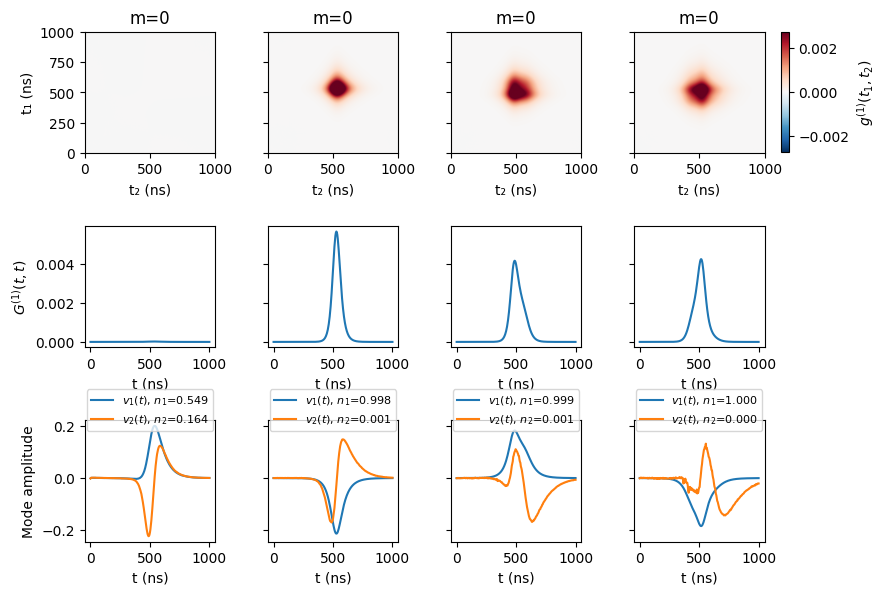

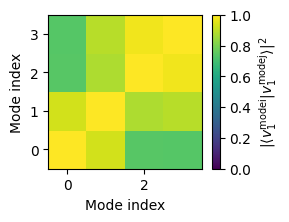

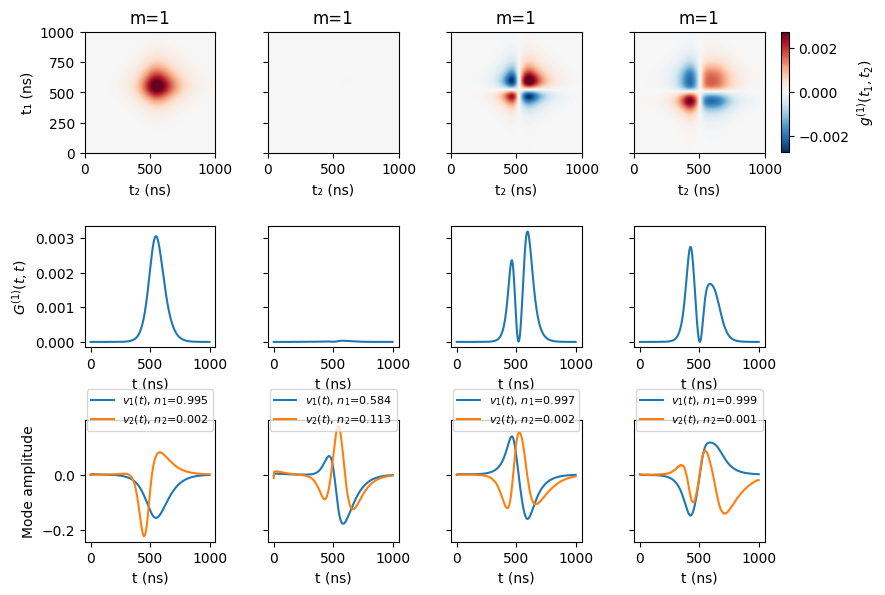

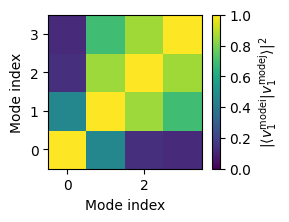

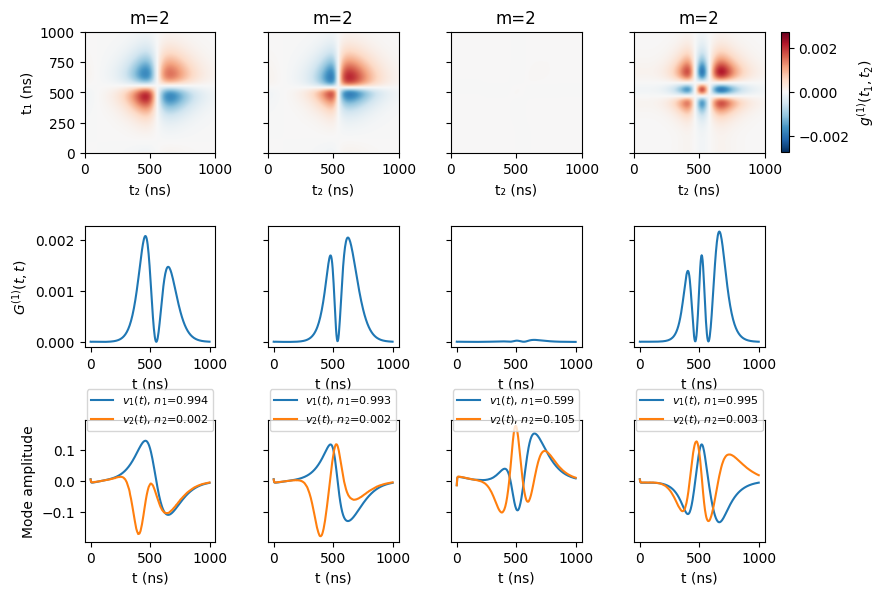

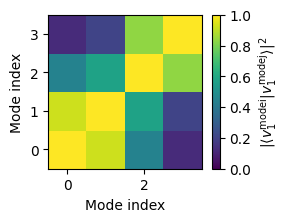

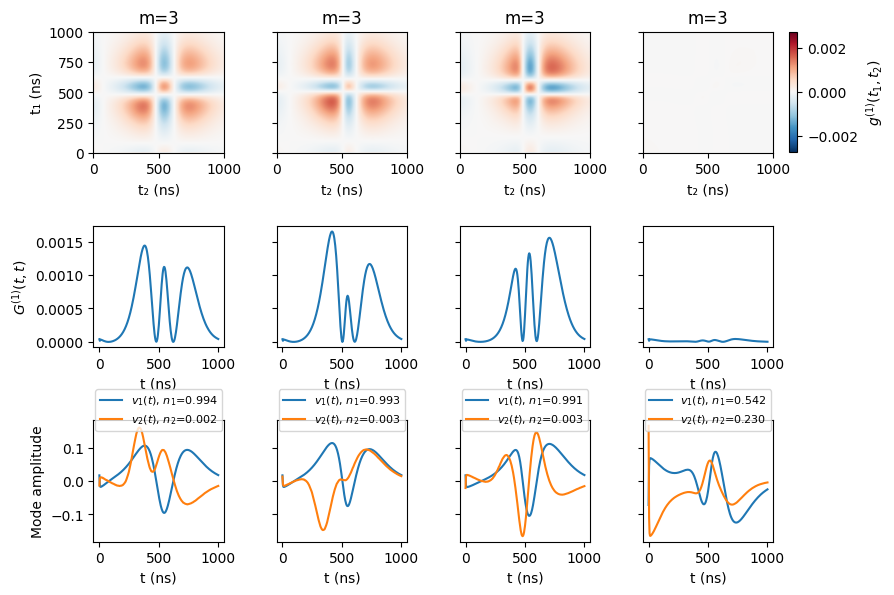

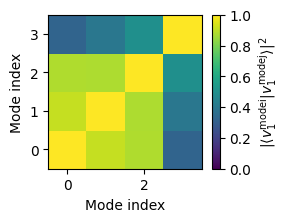

In [12]:
import h5py
results_output_abs = {}
with h5py.File("results_output_abs_vchalf.h5", "r") as f:
    for m_key in f.keys():
        for n_key in f[m_key].keys():
            m = int(m_key[1:])
            n = int(n_key[1:])
            results_output_abs[(m, n)] = f[f"{m_key}/{n_key}"][:]
principal_mode_dict = {}          
for m in range(4):
    fig, axes = plt.subplots(3, 4, figsize=(8, 6), sharey='row')
    plt.subplots_adjust(wspace=0.4, hspace=0.6, left=0.05, right=0.90, top=0.95, bottom=0.1)

    principal_modes = []

    Nt = len(tgrid)
    dt = tgrid[1] - tgrid[0]

    vmin = min(np.min(G1.real) for G1 in results_output_abs.values())
    vmax = max(np.max(G1.real) for G1 in results_output_abs.values())
    for n in range(4):
        G1 = results_output_abs[(m, n)]
        G1_new = np.zeros((Nt, Nt),  dtype=complex)

        for idx_b, t_b in enumerate(tgrid):
            for idx_a, t_a in enumerate(tgrid):
                tau_idx = int(idx_a - idx_b)
                if 0 <= tau_idx < Nt:
                    G1_new[idx_a, idx_b] = G1[idx_b, tau_idx]
                else:
                    G1_new[idx_a, idx_b] = np.conjugate(G1_new[idx_b, idx_a])


        eigs, eigvecs = np.linalg.eigh(G1_new)
        sort_idx = np.argsort(eigs)[::-1]
        eigvecs = eigvecs[:, sort_idx]
        eigs = eigs[sort_idx]
        eigs_frac = eigs / np.sum(eigs)

        im = axes[0, n].imshow(
            G1_new.real,
            extent=[tgrid[0], tgrid[-1], tgrid[0], tgrid[-1]],
            cmap="RdBu_r",
            origin="lower",
            aspect="auto",
            vmin=vmin,
            vmax=-vmin
        )
        axes[0, n].set_title(f"m={m}")
        axes[0, n].set_xlabel("t₂ (ns)")
        if n == 0:
            axes[0, n].set_ylabel("t₁ (ns)")

        diag_vals = np.real(np.diag(G1_new))
        axes[1, n].plot(tgrid, diag_vals, color='tab:blue')
        axes[1, n].set_xlabel("t (ns)")
        if n == 0:
            axes[1, n].set_ylabel(r"$G^{(1)}(t,t)$")

        lines = []
        labels = []
        for k in range(min(2, len(eigs))):
            v = eigvecs[:, k]
            v_norm = v #/ np.sqrt(np.trapz(np.abs(v)**2, tgrid))
            line, = axes[2, n].plot(tgrid, np.real(v_norm))
            lines.append(line)
            labels.append(f"$v_{{{k+1}}}(t)$, $n_{{{k+1}}}$={eigs_frac[k]:.3f}")
            if k==0:
                principal_mode_dict[(m, n)] = v_norm.copy()

        axes[2, n].legend(handles=lines, labels=labels, fontsize=8,
                        loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=1)
        axes[2, n].set_xlabel("t (ns)")
        if n == 0:
            axes[2, n].set_ylabel("Mode amplitude")

        principal_modes.append(eigvecs[:, 0] / np.sqrt(np.trapezoid(np.abs(eigvecs[:, 0])**2, tgrid)))
        # principal_modes.append(eigvecs[:, 0])

    cbar_ax = fig.add_axes([0.92, 0.75, 0.01, 0.2])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label(r"$g^{(1)}(t_1, t_2)$")

    plt.show()

    N_modes = len(principal_modes)
    overlap_matrix = np.zeros((N_modes, N_modes), dtype=float)

    for i in range(N_modes):
        for j in range(N_modes):
            overlap_matrix[i, j] = np.abs(np.trapezoid(np.conj(principal_modes[i]) * principal_modes[j], tgrid))

    fig2, ax2 = plt.subplots(figsize=(2.5, 2.))
    im2 = ax2.imshow(overlap_matrix**2, origin='lower', cmap='viridis', vmin=0, vmax=1)
    cbar2 = fig2.colorbar(im2)
    cbar2.set_label(r"$|\langle v_1^\mathrm{mode i} | v_1^\mathrm{mode j} \rangle|^2$")
    ax2.set_xlabel("Mode index")
    ax2.set_ylabel("Mode index")
    plt.show()


In [16]:
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.

best_x: [-3.78363103e-03 -6.60080832e+00]
best_x: [-3.99377031e-03 -5.81821696e+00]
best_x: [-3.84093253e-03 -6.20381099e+00]
best_x: [-1.19906176e-03 -5.15740056e+00]
best_x: [-3.67951427e-04  1.85296696e+01]
best_x: [-3.82743682e-03 -4.26749752e+00]
best_x: [-3.65266775e-03 -6.95459915e+00]
best_x: [-4.26820352e-03 -7.12236222e+00]


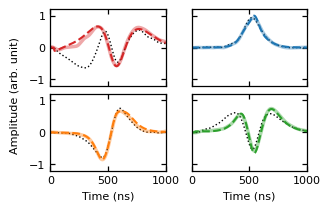

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(3., 2.) , constrained_layout=True, sharex=True,sharey=True) 

ph_amp = 0
fogi_freq = 17

abs_exps = []
ref_exps = []
fitted_abs_sims = []
for m in range(4):    

    n=3
    LdL = principal_mode_dict[(m, n)]
    t_exp = np.linspace(0, 1000, 501)
    abs_exp = acquisitions[m][n].get_results()["y_absorbed_signals"][ph_amp][fogi_freq][100:-149]
    ref_exp = acquisitions[m][n].get_results()["y_base_signals"][ph_amp][fogi_freq][100:-149]
    waveform_exp = np.interp(tgrid, t_exp, abs_exp)
    fitted_dummy, best_x = fit_waveform(tgrid, waveform_exp, LdL, x0=[-0.001, 10.0])
    scale, shift_val = best_x
    def apply_fit(waveform, scale, shift_val, time):
        waveform_resampled = np.interp(time, np.linspace(time[0], time[-1], len(waveform)), waveform)
        dt = time[1] - time[0]
        shift_idx = -shift_val #/ dt 
        return scale * nd_shift(waveform_resampled, shift=shift_idx, mode='constant', cval=0.0)
    
    fitted_abs_sim = apply_fit(LdL, scale, shift_val, tgrid)
    abs_exps.append(abs_exp)
    ref_exps.append(ref_exp)
    fitted_abs_sims.append(fitted_abs_sim)

abs_exps1 = []
ref_exps1 = []
fitted_abs_sims1 = []
for m in range(4):    

    n=0
    LdL = principal_mode_dict[(m, n)]
    t_exp = np.linspace(0, 1000, 501)
    abs_exp = acquisitions[m][n].get_results()["y_absorbed_signals"][ph_amp][fogi_freq][100:-149]
    ref_exp = acquisitions[m][n].get_results()["y_base_signals"][ph_amp][fogi_freq][100:-149]
    waveform_exp = np.interp(tgrid, t_exp, abs_exp)
    fitted_dummy, best_x = fit_waveform(tgrid, waveform_exp, LdL, x0=[-0.001, 10.0])
    scale, shift_val = best_x
    def apply_fit(waveform, scale, shift_val, time):
        waveform_resampled = np.interp(time, np.linspace(time[0], time[-1], len(waveform)), waveform)
        dt = time[1] - time[0]
        shift_idx = -shift_val #/ dt 
        return scale * nd_shift(waveform_resampled, shift=shift_idx, mode='constant', cval=0.0)
    
    fitted_abs_sim = apply_fit(LdL, scale, shift_val, tgrid)
    abs_exps1.append(abs_exp)
    ref_exps1.append(ref_exp)
    fitted_abs_sims1.append(fitted_abs_sim)
    
norm = np.max(np.abs(fitted_abs_sims[0]))
axs[0][0].plot(t_exp, -ref_exps1[3]/norm, lw=1., alpha=1, linestyle=":", color="black", label="exp_ref")
axs[0][0].plot(t_exp, abs_exps1[3]/norm, lw=2.5, alpha=0.4, color="tab:red", label="exp")
axs[0][0].plot(tgrid, -fitted_abs_sims1[3]/norm, lw=1.5, alpha=1 , linestyle="--", color="tab:red", label="sim")
axs[0][1].plot(t_exp, ref_exps[0]/norm, lw=1., alpha=1, linestyle=":", color="black", label="exp_ref")
axs[0][1].plot(t_exp, abs_exps[0]/norm, lw=2.5, alpha=0.4, color="tab:blue", label="exp")
axs[0][1].plot(tgrid,fitted_abs_sims[0]/norm, lw=1.5, alpha=1, linestyle="--", color="tab:blue", label="sim")
axs[1][0].plot(t_exp, -ref_exps[1]/norm, lw=1., alpha=1, linestyle=":", color="black", label="exp_ref")
axs[1][0].plot(t_exp, -abs_exps[1]/norm,  lw=2.5, alpha=0.4, color="tab:orange", label="exp")
axs[1][0].plot(tgrid, -fitted_abs_sims[1]/norm, lw=1.5, alpha=1, linestyle="--", color="tab:orange", label="sim")
axs[1][1].plot(t_exp, ref_exps[2]/norm, lw=1., alpha=1, linestyle=":", color="black", label="exp_ref")
axs[1][1].plot(t_exp, abs_exps[2]/norm, lw=2.5, alpha=0.4, color="tab:green", label="exp")
axs[1][1].plot(tgrid, fitted_abs_sims[2]/norm, lw=1.5, alpha=1, linestyle="--", color="tab:green", label="sim")

fig.text(-0.05, 0.55, "Amplitude (arb. unit)", va="center", rotation="vertical")
for ax in axs[-1, :]:
    ax.set_xlabel("Time (ns)")
    ax.set_ylim(-1.2, 1.2)
    ax.set_xlim(0, 1000)

for ax in axs.flat:
    ax.set_yticks([-1, 0, 1])

# plt.savefig('Fig4abcd.pdf', bbox_inches='tight')
plt.show()

best_x: [-3.78363103e-03 -6.60080832e+00]
best_x: [-3.99377031e-03 -5.81821696e+00]
best_x: [-3.84093253e-03 -6.20381099e+00]
best_x: [-1.19906176e-03 -5.15740056e+00]


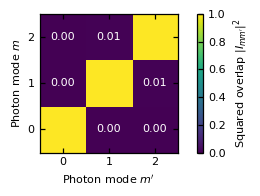

In [ ]:
def overlap(func1, func2):
    i = 0
    for t in range(len(func1)):
        i += func1[t] * np.conjugate(func2[t])
    return np.abs(i)

abs_exps = []
fitted_abs_sims = []
for m in range(4):    

    n=3
    LdL = principal_mode_dict[(m, n)]
    t_exp = np.linspace(0, 1000, 501)
    abs_exp = acquisitions[m][n].get_results()["y_absorbed_signals"][ph_amp][fogi_freq][100:-149]
    waveform_exp = np.interp(tgrid, t_exp, abs_exp)
    fitted_dummy, best_x = fit_waveform(tgrid, waveform_exp, LdL, x0=[-0.001, 10.0])
    scale, shift_val = best_x
    fitted_abs_sim = apply_fit(LdL, scale, shift_val, tgrid)
    abs_exps.append(abs_exp)
    fitted_abs_sims.append(fitted_abs_sim)


mode_num = 3
expI_matrix = np.zeros((mode_num, mode_num))
I_normalized = np.zeros((mode_num, mode_num))
m_list = [0, 1, 2]

for i, m in enumerate(m_list):
    for j, m_prime in enumerate(m_list):
        wf_m = abs_exps[m]
        wf_m_prime = abs_exps[m_prime]

        expI_matrix[i, j] = overlap(wf_m, wf_m_prime)
        norm_product = np.linalg.norm(wf_m) * np.linalg.norm(wf_m_prime)
        I_normalized[i, j] = expI_matrix[i, j] / norm_product
squaredI_matrix = I_normalized**2
plt.figure(figsize=(4, 2))
plt.imshow(squaredI_matrix, cmap='viridis', origin='lower', vmin=0, vmax=1)
for i in range(mode_num):
    for j in range(mode_num):
        if i != j:
            if squaredI_matrix[j, i]>0.5:
                plt.text(i, j, f"{squaredI_matrix[j, i]:.2f}", ha='center', va='center', color="red")
            else:
                plt.text(i, j, f"{squaredI_matrix[j, i]:.2f}", ha='center', va='center', color="white")

plt.colorbar(label=r'Squared overlap $|I_{mm^{\prime}}|^2$')
plt.xlabel(r"Photon mode $m^{\prime}$")
plt.ylabel(r"Photon mode $m$")
plt.xticks(range(len(squaredI_matrix)))
plt.yticks(range(len(squaredI_matrix)))
plt.tight_layout()
# plt.savefig('Fig4e.pdf', bbox_inches='tight')
plt.show()